In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
benchmark = pd.read_csv("data/processed/10_benchmark_indices_clean.csv")
fund_master = pd.read_csv("data/processed/01_fund_master_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)
print("Fund Master:", fund_master.shape)

NAV: (46000, 3)
Performance: (40, 20)
Benchmark: (8050, 3)
Fund Master: (40, 15)


In [4]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [5]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

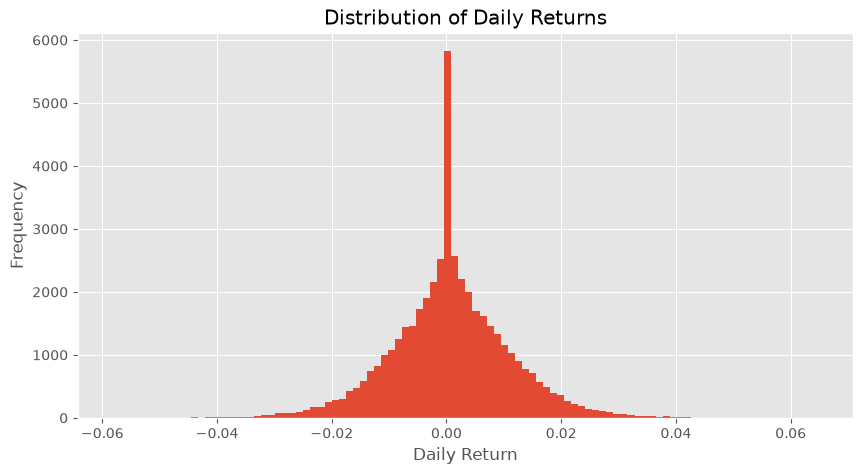

In [6]:
plt.figure(figsize=(10,5))

plt.hist(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [7]:
print("Minimum Daily Return:", nav["daily_return"].min())
print("Maximum Daily Return:", nav["daily_return"].max())

Minimum Daily Return: -0.058102013949189124
Maximum Daily Return: 0.06471309359097144


In [8]:
cagr_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (df.iloc[-1]["date"] - df.iloc[0]["date"]).days / 365.25

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_list.append([code, cagr])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [9]:
cagr_df = cagr_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

cagr_df = cagr_df.sort_values(
    "cagr_pct",
    ascending=False
)

cagr_df.head(10)

,amfi_code,cagr_pct,scheme_name
25,120505,32.827406,ICICI Pru Midcap Fund - Regular - Growth
21,119598,32.423536,SBI Small Cap Fund - Regular Plan - Growth
39,149324,32.287440,DSP Small Cap Fund - Regular - Growth
36,148569,31.949523,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,30.974108,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,30.907455,Kotak Flexicap Fund - Regular - Growth
2,100033,30.123153,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,29.581087,DSP Midcap Fund - Regular - Growth
16,119094,28.214417,Axis Midcap Fund - Regular - Growth
19,119551,25.804686,SBI Bluechip Fund - Regular Plan - Growth


In [10]:
cagr_df.to_csv(
    "cagr_comparison.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [11]:
risk_free_rate = 0.065

sharpe_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]

    returns = df["daily_return"].dropna()

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (annual_return - risk_free_rate) / annual_volatility

    sharpe_list.append([code, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [12]:
sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [13]:
sharpe_df.to_csv(
    "sharpe_ratio.csv",
    index=False
)

print("Sharpe ratios saved!")

Sharpe ratios saved!


In [14]:
sortino_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]

    returns = df["daily_return"].dropna()

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    sortino = (annual_return - risk_free_rate) / downside_std

    sortino_list.append([code, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [15]:
sortino_df = sortino_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [16]:
sortino_df.to_csv(
    "sortino_ratio.csv",
    index=False
)

print("Sortino ratios saved!")

Sortino ratios saved!


In [17]:
print(benchmark.columns.tolist())
benchmark.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [18]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [19]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [20]:
alpha_beta_list = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_list.append([code, alpha, beta])

In [21]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

alpha_beta_df.head(10)

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth
5,101208,0.060861,0.000267,ABSL Liquid Fund - Regular - Growth
6,102885,0.170488,-0.019487,UTI Nifty 50 Index Fund - Regular - Growth
7,102886,0.028969,-0.042125,UTI Mid Cap Fund - Regular - Growth
8,102887,0.162113,0.016683,UTI Flexi Cap Fund - Regular - Growth
9,118632,0.218294,-0.008354,Nippon India Large Cap Fund - Regular - Growth


In [22]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

print("Alpha & Beta saved successfully!")

Alpha & Beta saved successfully!


In [23]:
drawdown_list = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].sort_values("date").copy()

    df["running_max"] = df["nav"].cummax()
    df["drawdown"] = (df["nav"] / df["running_max"]) - 1

    max_drawdown = df["drawdown"].min()

    worst_row = df.loc[df["drawdown"].idxmin()]

    drawdown_list.append([
        code,
        max_drawdown,
        worst_row["date"]
    ])

In [24]:
drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "max_drawdown",
        "worst_date"
    ]
)

drawdown_df = drawdown_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

drawdown_df = drawdown_df.sort_values(
    "max_drawdown"
)

drawdown_df.head(10)

,amfi_code,max_drawdown,worst_date,scheme_name
22,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,2023-05-22,Axis Bluechip Fund - Direct - Growth


In [25]:
drawdown_df.to_csv(
    "max_drawdown.csv",
    index=False
)

print("Maximum Drawdown saved!")

Maximum Drawdown saved!


In [26]:
scorecard = cagr_df.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    performance[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr_pct,scheme_name,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,120505,32.827406,ICICI Pru Midcap Fund - Regular - Growth,1.180101,0.292636,-0.181885,1.36
1,119598,32.423536,SBI Small Cap Fund - Regular Plan - Growth,0.945308,0.303370,-0.287060,1.43
2,149324,32.287440,DSP Small Cap Fund - Regular - Growth,0.949796,0.300579,-0.311719,1.52
3,148569,31.949523,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,0.282704,-0.163967,1.60
4,148567,30.974108,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,0.269838,-0.112657,1.46


In [27]:
scorecard["return_rank"] = scorecard["cagr_pct"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

In [28]:
scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["drawdown_rank"]
)

scorecard = scorecard.sort_values("fund_score")

scorecard.head(10)

,amfi_code,cagr_pct,scheme_name,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,120505,32.827406,ICICI Pru Midcap Fund - Regular - Growth,1.180101,0.292636,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,6.900
4,148567,30.974108,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,0.269838,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,7.400
5,120843,30.907455,Kotak Flexicap Fund - Regular - Growth,1.306744,0.273305,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,7.900
6,100033,30.123153,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,0.271954,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,9.600
3,148569,31.949523,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,0.282704,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,10.325
1,119598,32.423536,SBI Small Cap Fund - Regular Plan - Growth,0.945308,0.303370,-0.287060,1.43,2.0,14.0,1.0,21.0,36.0,11.050
12,120504,23.295119,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,0.211948,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,12.000
14,119552,21.524236,SBI Bluechip Fund - Direct Plan - Growth,0.953279,0.198686,-0.118035,0.66,15.0,12.0,15.0,4.0,11.0,12.200
2,149324,32.287440,DSP Small Cap Fund - Regular - Growth,0.949796,0.300579,-0.311719,1.52,3.0,13.0,2.0,26.5,37.0,12.225
9,119551,25.804686,SBI Bluechip Fund - Regular Plan - Growth,1.208267,0.232010,-0.150124,1.54,10.0,4.0,10.0,30.5,17.0,12.275


In [29]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved!")

Fund Scorecard saved!


In [30]:
top5 = scorecard.nsmallest(5, "fund_score")

top5

,amfi_code,cagr_pct,scheme_name,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,120505,32.827406,ICICI Pru Midcap Fund - Regular - Growth,1.180101,0.292636,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,6.900
4,148567,30.974108,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,0.269838,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,7.400
5,120843,30.907455,Kotak Flexicap Fund - Regular - Growth,1.306744,0.273305,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,7.900
6,100033,30.123153,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,0.271954,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,9.600
3,148569,31.949523,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,0.282704,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,10.325


In [31]:
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty50["date"] = pd.to_datetime(nifty50["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

nifty50["normalized"] = nifty50["close_value"] / nifty50.iloc[0]["close_value"] * 100
nifty100["normalized"] = nifty100["close_value"] / nifty100.iloc[0]["close_value"] * 100

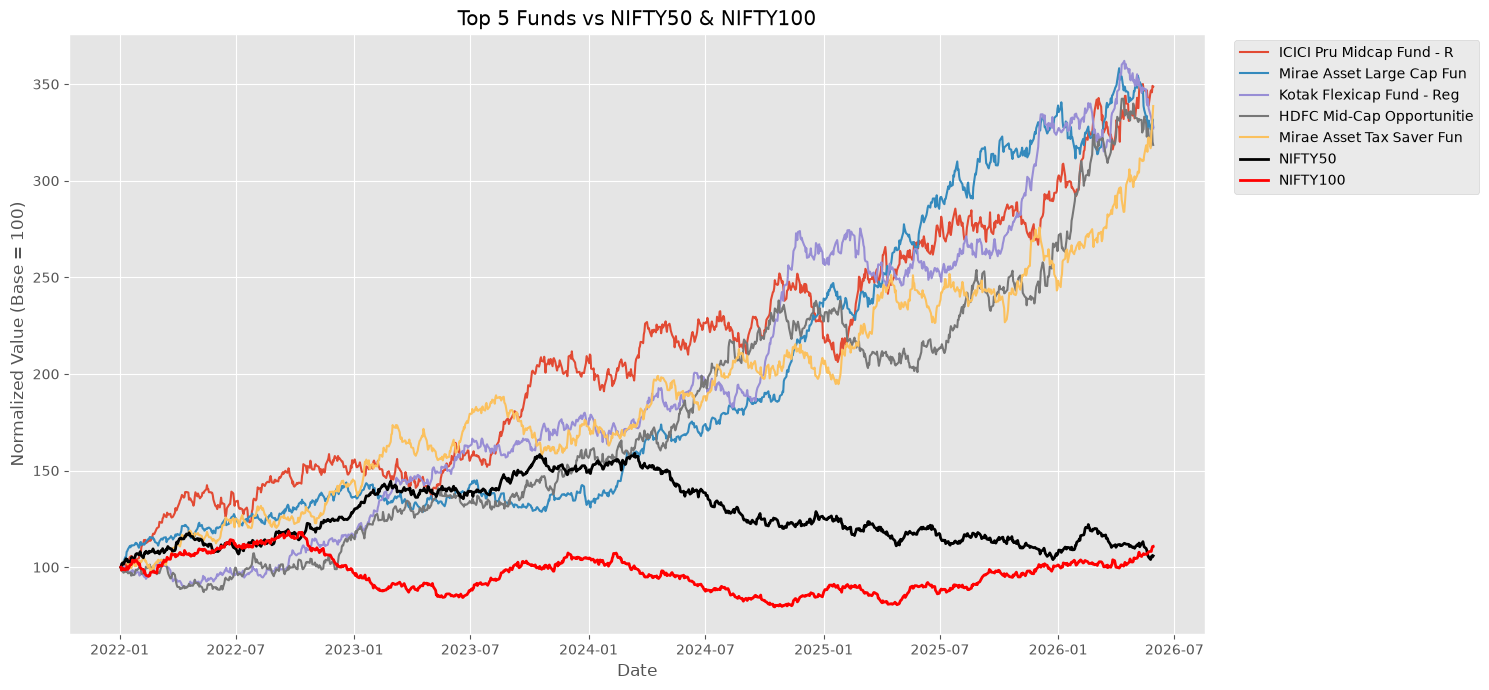

In [32]:
plt.figure(figsize=(15,7))

for code in top5["amfi_code"]:

    fund = nav[nav["amfi_code"] == code].copy()
    fund = fund.sort_values("date")

    fund["normalized"] = fund["nav"] / fund.iloc[0]["nav"] * 100

    name = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund["date"],
        fund["normalized"],
        label=name[:25]
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    color="black",
    linewidth=2,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    color="red",
    linewidth=2,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "charts/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [33]:
tracking_error = []

for code in top5["amfi_code"]:

    fund = nav[nav["amfi_code"] == code][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date"
    ).dropna()

    te = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error.append([
        code,
        te
    ])

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

KeyError: "['benchmark_return'] not in index"